In [1]:
# Cell 1 — Imports & load from DB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sys
sys.path.append('../src')
from db_utils import get_engine

engine = get_engine()
df = pd.read_sql("SELECT * FROM raw_employees", con=engine)
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Cell 2 — Basic info
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nAttrition distribution:\n", df['Attrition'].value_counts())

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

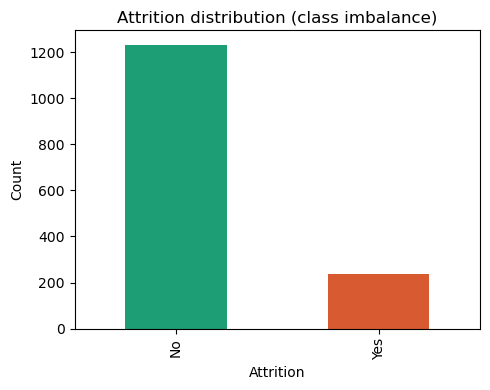

In [3]:
# Cell 3 — Target imbalance (this is crucial to show in your project)
fig, ax = plt.subplots(figsize=(5, 4))
df['Attrition'].value_counts().plot(kind='bar', ax=ax, color=['#1D9E75', '#D85A30'])
ax.set_title('Attrition distribution (class imbalance)')
ax.set_xlabel('Attrition')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/attrition_distribution.png', dpi=150)
plt.show()

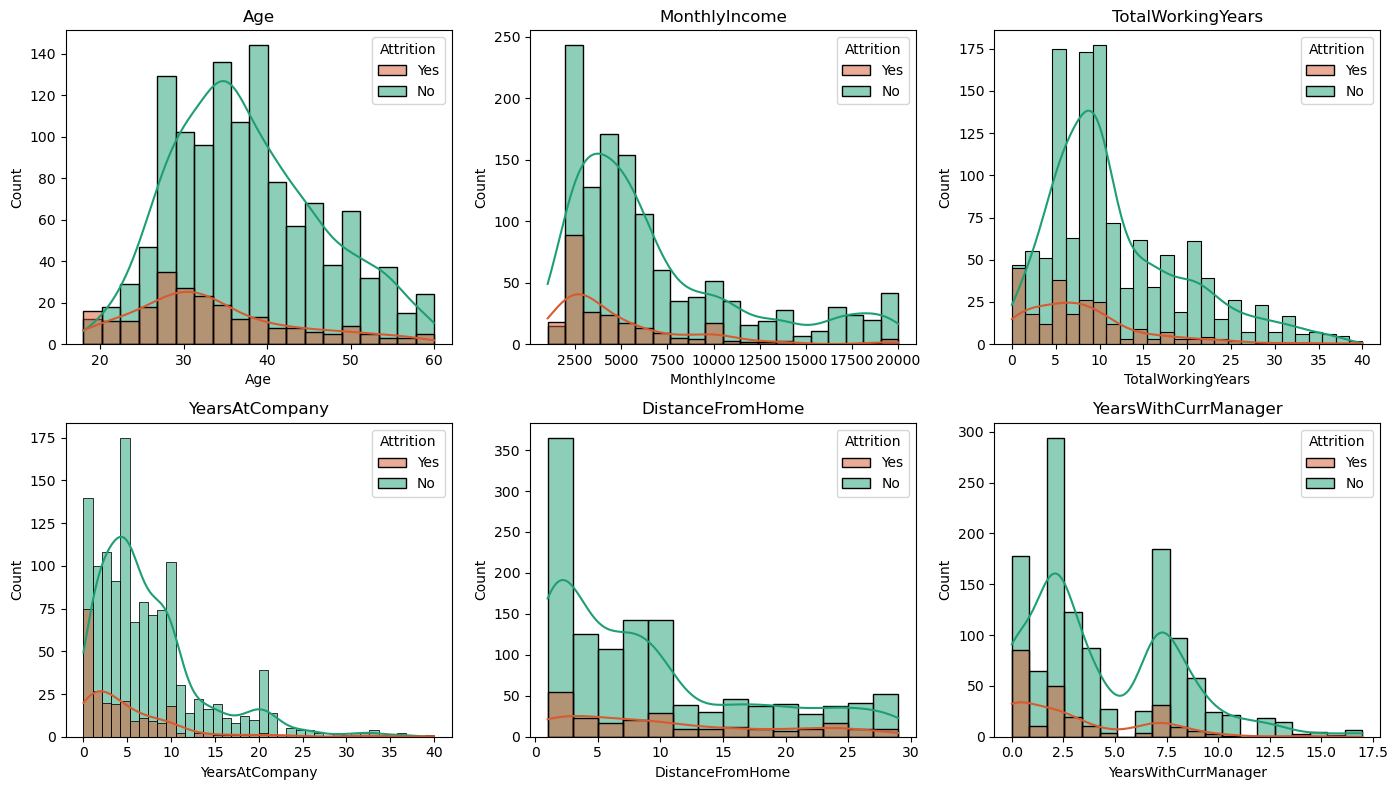

In [4]:
# Cell 4 — Numerical feature distributions
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
            'YearsAtCompany', 'DistanceFromHome', 'YearsWithCurrManager']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data=df, x=col, hue='Attrition', kde=True, ax=ax,
                 palette={'Yes': '#D85A30', 'No': '#1D9E75'})
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../data/numeric_distributions.png', dpi=150)
plt.show()

C:\Users\HARSHAL\AppData\Local\Temp\ipykernel_20444\3085625079.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_attr, x='Department', y='AttritionRate',
C:\Users\HARSHAL\AppData\Local\Temp\ipykernel_20444\3085625079.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=role_attr, x='AttritionRate', y='JobRole',


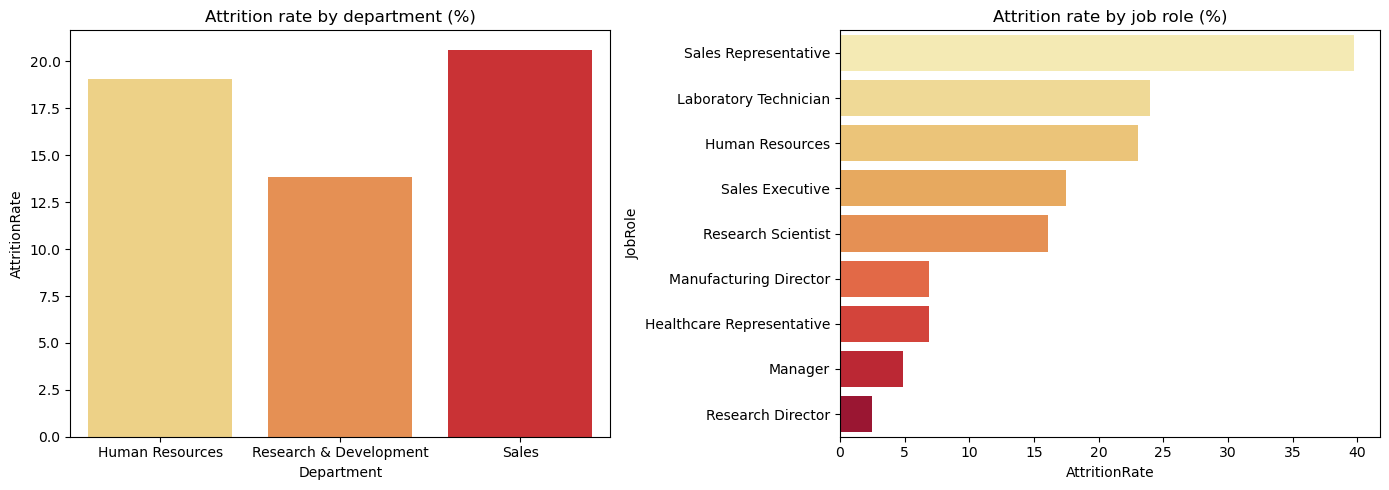

In [5]:
# Cell 5 — Attrition rate by department and job role
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
dept_attr.columns = ['Department', 'AttritionRate']
sns.barplot(data=dept_attr, x='Department', y='AttritionRate',
            palette='YlOrRd', ax=axes[0])
axes[0].set_title('Attrition rate by department (%)')

role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False).reset_index()
role_attr.columns = ['JobRole', 'AttritionRate']
sns.barplot(data=role_attr, x='AttritionRate', y='JobRole',
            palette='YlOrRd', ax=axes[1])
axes[1].set_title('Attrition rate by job role (%)')
plt.tight_layout()
plt.savefig('../data/attrition_by_role_dept.png', dpi=150)
plt.show()

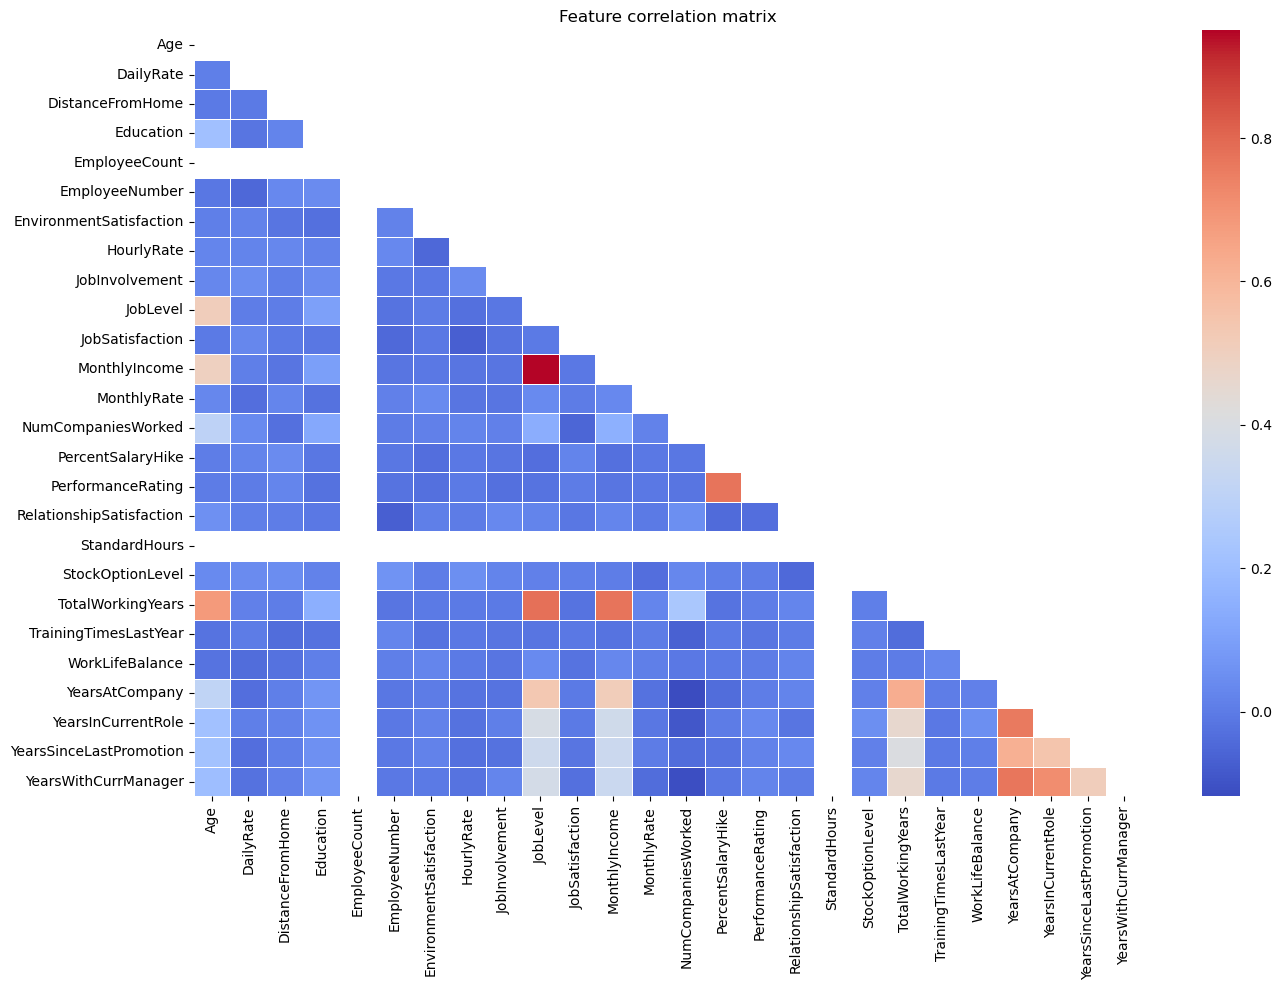

In [6]:
# Cell 6 — Correlation heatmap (numeric only)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, cmap='coolwarm',
            annot=False, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

In [7]:
# Cell 7 — Key business insight summary (put this in your README later)
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
high_risk_roles = role_attr.head(3)['JobRole'].tolist()
avg_income_left = df[df['Attrition']=='Yes']['MonthlyIncome'].mean()
avg_income_stayed = df[df['Attrition']=='No']['MonthlyIncome'].mean()

print(f"Overall attrition rate: {attrition_rate:.1f}%")
print(f"Top 3 highest-risk roles: {high_risk_roles}")
print(f"Avg monthly income - left: ${avg_income_left:,.0f}")
print(f"Avg monthly income - stayed: ${avg_income_stayed:,.0f}")

Overall attrition rate: 16.1%
Top 3 highest-risk roles: ['Sales Representative', 'Laboratory Technician', 'Human Resources']
Avg monthly income - left: $4,787
Avg monthly income - stayed: $6,833
